# vaspparser demo

This notebook walks through the main building blocks of the `vaspparser` package using the
sample VASP output files that ship with the test suite (`tests/static/vasp_test_files`).

It covers:

1. Reading and writing VASP structure files (`POSCAR`/`CONTCAR`)
2. Parsing a full VASP run with `parse_vasp_output`
3. Parsing individual files: `OSZICAR`, `OUTCAR`, `vasprun.xml`, `PROCAR`
4. Working with the electronic structure: density of states (DOS) and the band gap
5. Reading volumetric data (`CHGCAR`)
6. Bader charge analysis helpers


In [1]:
import os

import numpy as np

# Sample VASP output files used throughout the test suite
TEST_FILES = os.path.join("tests", "static", "vasp_test_files")
FULL_JOB_SAMPLE = os.path.join(TEST_FILES, "full_job_sample")


## 1. Reading and writing structures

VASP structures are stored in the `POSCAR`/`CONTCAR` format. `read_atoms` parses such a file into an [ASE](https://wiki.fysik.dtu.dk/ase/) `Atoms` object, and `write_poscar` does the reverse.

In [2]:
from vaspparser.vasp.structure import read_atoms, write_poscar, vasp_sorter

structure = read_atoms(os.path.join(FULL_JOB_SAMPLE, "POSCAR"), species_list=["Fe"])
structure


Atoms(symbols='Fe2', pbc=True, cell=[2.8, 2.8, 2.8])

In [3]:
# vasp_sorter() gives the permutation that groups atoms by species, which is how VASP
# expects atoms to be ordered inside a POSCAR file
vasp_sorter(structure)


array([0, 1])

In [4]:
write_poscar(structure=structure, filename="POSCAR_demo")
roundtrip = read_atoms("POSCAR_demo")
assert roundtrip == structure
os.remove("POSCAR_demo")
roundtrip


Atoms(symbols='Fe2', pbc=True, cell=[2.8, 2.8, 2.8])

## 2. Parsing a full VASP run

`parse_vasp_output` is the main entry point of the package: point it at a calculation
directory and it returns a single, hierarchical dictionary with everything that could be
parsed (energies, forces, structure, electronic structure, charge density, ...).


In [5]:
from vaspparser.vasp.output import parse_vasp_output

output_dict = parse_vasp_output(working_directory=FULL_JOB_SAMPLE)
list(output_dict.keys())


['description',
 'generic',
 'structure',
 'charge_density',
 'electronic_structure',
 'outcar']

In [6]:
# Generic, code-agnostic quantities (energies, forces, positions, ...)
list(output_dict["generic"].keys())


['temperature',
 'stresses',
 'pressures',
 'elastic_constants',
 'forces',
 'cells',
 'volume',
 'energy_pot',
 'energy_tot',
 'steps',
 'positions',
 'dft']

In [7]:
energy_tot = output_dict["generic"]["energy_tot"]
print(f"Number of ionic steps: {len(energy_tot)}")
print(f"Final total energy: {energy_tot[-1]:.6f} eV")


Number of ionic steps: 1
Final total energy: -17.737987 eV


## 3. Parsing individual output files

Each VASP file also has a dedicated parser that can be used on its own.

### OSZICAR

The `OSZICAR` file tracks the energy at every electronic/ionic step.

In [8]:
from vaspparser.vasp.parser.oszicar import Oszicar

oszicar = Oszicar()
oszicar.from_file(filename=os.path.join(FULL_JOB_SAMPLE, "OSZICAR"))
oszicar.parse_dict["energy_pot"]


array([-17.73798679])

### OUTCAR

The `OUTCAR` file contains most of what VASP printed during the run: energies, forces, stresses, the Fermi level, magnetic moments, and more.

In [9]:
from vaspparser.vasp.parser.outcar import Outcar

outcar = Outcar()
outcar.from_file(filename=os.path.join(FULL_JOB_SAMPLE, "OUTCAR"))
print("Fermi level (eV):", outcar.parse_dict["fermi_level"])
print("Number of electrons:", outcar.parse_dict["n_elect"])
print("Final pressure:", outcar.parse_dict["pressures"][-1])


Fermi level (eV): 5.9788
Number of electrons: 16.0
Final pressure: [-0.08177043 -0.08177043 -0.08177043]


### vasprun.xml

`vasprun.xml` is VASP's structured XML output and is the preferred source for energies, forces, and the electronic structure when available.

In [10]:
from vaspparser.vasp.vasprun import Vasprun

vasprun_path = os.path.join(TEST_FILES, "vasprun_samples", "vasprun_2.xml")
vasprun = Vasprun()
vasprun.from_file(filename=vasprun_path)
print("Final energy (eV):", vasprun.vasprun_dict["total_fr_energies"][-1])


Final energy (eV): -67.64570454


## 4. Electronic structure: DOS and band gap

`Vasprun.get_electronic_structure()` returns an `ElectronicStructure` object with the
eigenvalues/occupancies for every k-point and spin channel. From there we can compute the
density of states and the band gap.


In [11]:
electronic_structure = vasprun.get_electronic_structure()
print("Eigenvalue matrix shape (spin, kpoints, bands):", electronic_structure.eigenvalue_matrix.shape)
electronic_structure.get_band_gap()


Eigenvalue matrix shape (spin, kpoints, bands): (1, 36, 72)


{0: {'band_gap': np.float64(0.007800000000000001),
  'vbm': {'value': np.float64(-0.1611),
   'kpoint': <vaspparser.dft.waves.electronic.Kpoint at 0x7a6cb4267690>,
   'band': <vaspparser.dft.waves.electronic.Band at 0x7a6cb412fa10>},
  'cbm': {'value': np.float64(-0.1533),
   'kpoint': <vaspparser.dft.waves.electronic.Kpoint at 0x7a6cb4267380>,
   'band': <vaspparser.dft.waves.electronic.Band at 0x7a6cb410c110>}}}

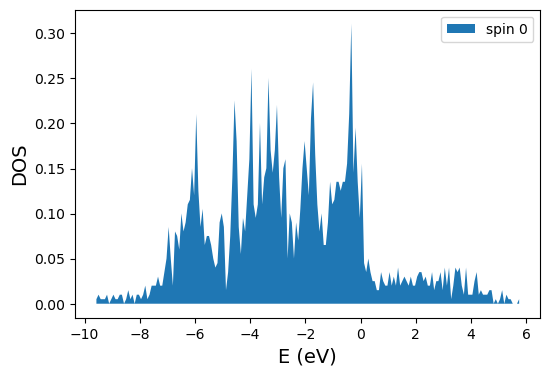

In [12]:
from vaspparser.dft.waves.dos import Dos

dos = Dos(es_obj=electronic_structure, n_bins=200)
plot = dos.plot_total_dos()
plot.show()


### PROCAR

The `PROCAR` file holds atom- and orbital-projected band/DOS information, useful for analysing the chemical character of bands.

In [13]:
from vaspparser.vasp.procar import Procar

procar = Procar()
procar_es = procar.from_file(filename=os.path.join(TEST_FILES, "PROCAR_for_test"))
band = procar_es.kpoints[0].bands[0][0]
print("Eigenvalue:", band.eigenvalue, "Occupancy:", band.occupancy)
print("Per-atom resolved DOS:", band.atom_resolved_dos)


Eigenvalue: -17.37867948 Occupancy: 1.0
Per-atom resolved DOS: [0.145 0.298 0.298]


## 5. Volumetric data: charge density

`CHGCAR`/`LOCPOT`-style files describe a quantity on a real-space grid. `VaspVolumetricData`
parses them and offers helpers such as averaging the density along one lattice direction
(handy for e.g. work-function or interface analysis).


In [14]:
from vaspparser.vasp.volumetric_data import VaspVolumetricData

charge_density = VaspVolumetricData()
charge_density.from_file(filename=os.path.join(FULL_JOB_SAMPLE, "CHGCAR"), normalize=True)
print("Grid shape:", charge_density.total_data.shape)

average_along_c = charge_density.get_average_along_axis(ind=2)
average_along_c


Grid shape: (28, 28, 28)


array([1.00830804, 0.98088211, 0.90377918, 0.79195173, 0.66754708,
       0.55462055, 0.47555225, 0.44711719, 0.47555225, 0.55462055,
       0.66754708, 0.79195173, 0.90377918, 0.98088211, 1.00830804,
       0.98088211, 0.90377918, 0.79195173, 0.66754708, 0.55462055,
       0.47555225, 0.44711719, 0.47555225, 0.55462055, 0.66754708,
       0.79195173, 0.90377918, 0.98088211])

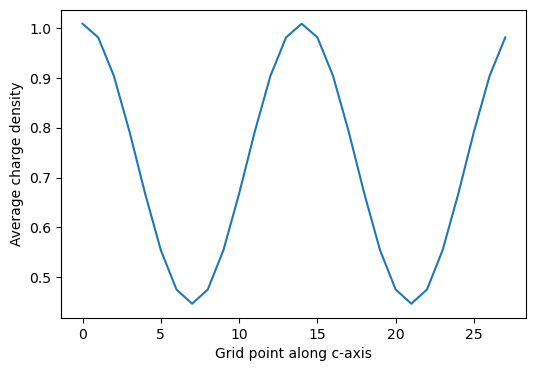

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(average_along_c)
plt.xlabel("Grid point along c-axis")
plt.ylabel("Average charge density")
plt.show()


## 6. Bader charge analysis

Bader analysis partitions the charge density into atomic basins. Running the actual
analysis requires the external `bader` executable, but `vaspparser` also exposes helpers
to parse its output (`ACF.dat`) and to combine `AECCAR0`/`AECCAR2` into the valence and
total charge density used as the Bader input.


In [16]:
from vaspparser.dft.bader import parse_charge_vol_file, get_valence_and_total_charge_density

bader_test_path = os.path.join(TEST_FILES, "bader_test")
bader_structure = read_atoms(os.path.join(bader_test_path, "POSCAR"))

acf_file = os.path.join("tests", "static", "dft", "bader_files", "ACF.dat")
charges, volumes = parse_charge_vol_file(structure=bader_structure, filename=acf_file)
print("Bader charges:", charges)
print("Bader volumes:", volumes)


Bader charges: [0.438202 0.438197 7.143794]
Bader volumes: [287.28469  297.577878 415.155432]


In [17]:
charge_density_valence, charge_density_total = get_valence_and_total_charge_density(
    working_directory=bader_test_path
)
print("Valence charge density grid:", charge_density_valence.total_data.shape)
print("Total (core + valence) charge density grid:", charge_density_total.total_data.shape)


Valence charge density grid: (20, 20, 20)
Total (core + valence) charge density grid: (20, 20, 20)
